<a id="top"></a>
<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">Emotion Classifier</br></br> <I style = "font-size: 20px">by: Ahmed Sharaf</I></div>



<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">Import Libraries</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, f1_score)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout, Bidirectional)
from transformers import (DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments)


<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">Configurations</div>


In [2]:
MAX_LEN = 128
VOCAB_SIZE = 20000
EMBEDDING_DIM = 128
BATCH_SIZE = 32
EPOCHS_LSTM = 10
EPOCHS_BERT = 3
RANDOM_STATE = 42

<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">Load Dataset</div>


In [3]:
dataset = load_dataset("dair-ai/emotion")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [4]:
train_df = pd.DataFrame(dataset["train"])
val_df = pd.DataFrame(dataset["validation"])
test_df = pd.DataFrame(dataset["test"])

<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">EDA</div>


In [5]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(16000, 2)
(2000, 2)
(2000, 2)


In [6]:
train_df.isnull().sum()

,0
text,0
label,0


In [7]:
train_df["label"].value_counts()

,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


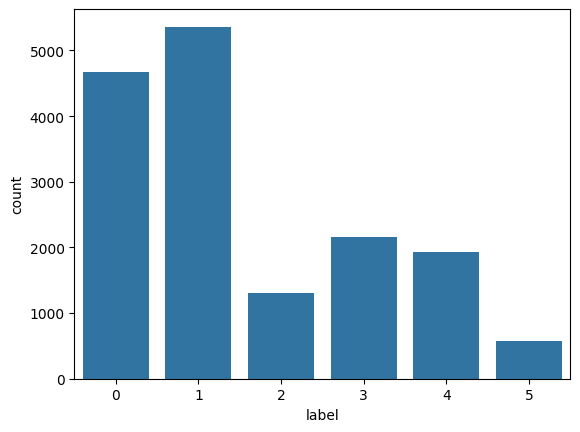

In [8]:
sns.countplot(data=train_df, x="label")
plt.show()

In [9]:
emotion_map = {
    0:"sadness",
    1:"joy",
    2:"love",
    3:"anger",
    4:"fear",
    5:"surprise"
}

<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">Data Preparation For BiLSTM</div>


In [10]:
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")

In [11]:
tokenizer.fit_on_texts(train_df["text"])

In [12]:
X_train = tokenizer.texts_to_sequences(train_df["text"])
X_val = tokenizer.texts_to_sequences(val_df["text"])
X_test = tokenizer.texts_to_sequences(test_df["text"])

In [13]:
X_train = pad_sequences(X_train, maxlen=MAX_LEN, padding="post")
X_val = pad_sequences(X_val, maxlen=MAX_LEN, padding="post")
X_test = pad_sequences(X_test, maxlen=MAX_LEN, padding="post")

In [14]:
y_train = to_categorical(train_df["label"])
y_val = to_categorical(val_df["label"])
y_test = to_categorical(test_df["label"])

<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">BiLSTM Model</div>


In [15]:
lstm_model = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(128)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(6, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [16]:
lstm_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_LSTM,
    batch_size=BATCH_SIZE
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.5504 - loss: 1.1814 - val_accuracy: 0.7545 - val_loss: 0.6968
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.8815 - loss: 0.3498 - val_accuracy: 0.9115 - val_loss: 0.2822
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9441 - loss: 0.1618 - val_accuracy: 0.9040 - val_loss: 0.2913
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9639 - loss: 0.1041 - val_accuracy: 0.9145 - val_loss: 0.2803
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9737 - loss: 0.0763 - val_accuracy: 0.9130 - val_loss: 0.2836
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9789 - loss: 0.0656 - val_accuracy: 0.9135 - val_loss: 0.2831
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9806 - loss: 0.0583 - val_accuracy: 0.9130 - val_loss: 0.3482
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.9864 - loss: 0.0429 - val

In [18]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test,y_test)
y_pred = lstm_model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9040 - loss: 0.4357
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


In [19]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       581
           1       0.92      0.93      0.92       695
           2       0.79      0.69      0.74       159
           3       0.95      0.87      0.91       275
           4       0.86      0.89      0.87       224
           5       0.70      0.77      0.73        66

    accuracy                           0.90      2000
   macro avg       0.86      0.85      0.86      2000
weighted avg       0.90      0.90      0.90      2000



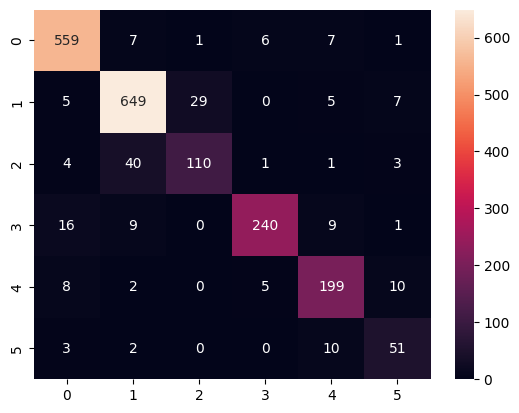

In [20]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.show()

<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">DistBERT</div>


In [21]:
tokenizer_bert = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [22]:
def tokenize(batch):
    return tokenizer_bert(batch["text"], truncation=True, padding="max_length", max_length=128)

In [23]:
tokenized_dataset = dataset.map(tokenize, batched=True)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [24]:
bert_model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=6)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [25]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch"
)

In [26]:
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"]
)

In [27]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.249088,0.193091
2,0.148927,0.167685
3,0.096112,0.160044


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3000, training_loss=0.242392214457194, metrics={'train_runtime': 582.1366, 'train_samples_per_second': 82.455, 'train_steps_per_second': 5.153, 'total_flos': 1589722177536000.0, 'train_loss': 0.242392214457194, 'epoch': 3.0})

In [28]:
bert_results = trainer.evaluate()

In [29]:
bert_results

{'eval_loss': 0.1600436121225357,
 'eval_runtime': 7.7444,
 'eval_samples_per_second': 258.25,
 'eval_steps_per_second': 16.141,
 'epoch': 3.0}

<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">Evaluation Models</div>


In [30]:
y_pred_probs = lstm_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [31]:
lstm_accuracy = accuracy_score(y_true, y_pred)
lstm_f1 = f1_score(y_true, y_pred, average="macro")

print("Accuracy:", lstm_accuracy)
print("Macro F1:", lstm_f1)

Accuracy: 0.904
Macro F1: 0.8550536355720042


In [32]:
target_names=[
            "sadness",
            "joy",
            "love",
            "anger",
            "fear",
            "surprise"
        ]
print(classification_report(y_true, y_pred,  target_names=target_names))

              precision    recall  f1-score   support

     sadness       0.94      0.96      0.95       581
         joy       0.92      0.93      0.92       695
        love       0.79      0.69      0.74       159
       anger       0.95      0.87      0.91       275
        fear       0.86      0.89      0.87       224
    surprise       0.70      0.77      0.73        66

    accuracy                           0.90      2000
   macro avg       0.86      0.85      0.86      2000
weighted avg       0.90      0.90      0.90      2000



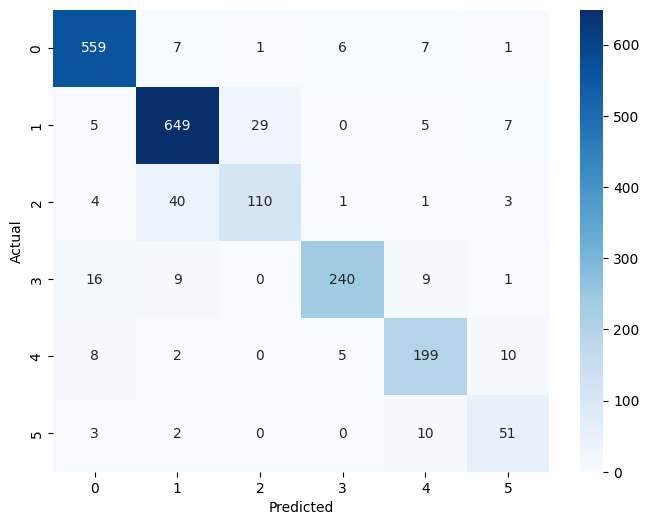

In [33]:
cm = confusion_matrix(y_true,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [34]:
predictions = trainer.predict(tokenized_dataset["test"])
y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

In [35]:
bert_accuracy = accuracy_score(y_true, y_pred)
bert_f1 = f1_score(y_true, y_pred, average="macro")

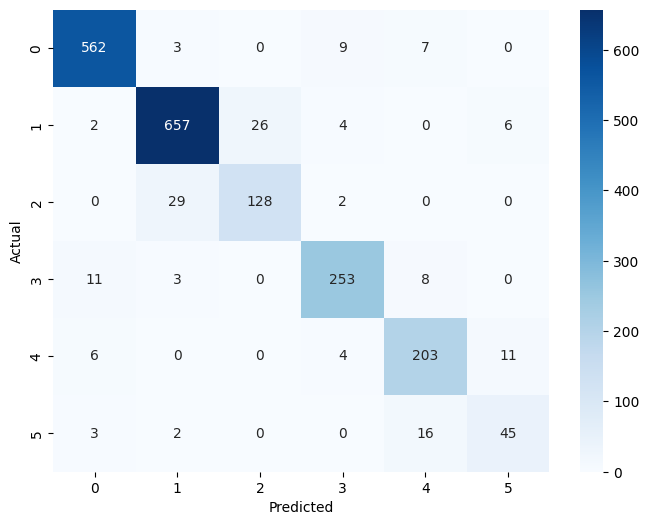

In [36]:
cm_bert = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm_bert, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [37]:
comparison_df = pd.DataFrame({
    "Model":["BiLSTM", "DistilBERT"],
    "Accuracy":[lstm_accuracy, bert_accuracy],
    "Macro_F1":[lstm_f1, bert_f1]
})

In [38]:
comparison_df

,Model,Accuracy,Macro_F1
0,BiLSTM,0.904,0.855054
1,DistilBERT,0.924,0.873889


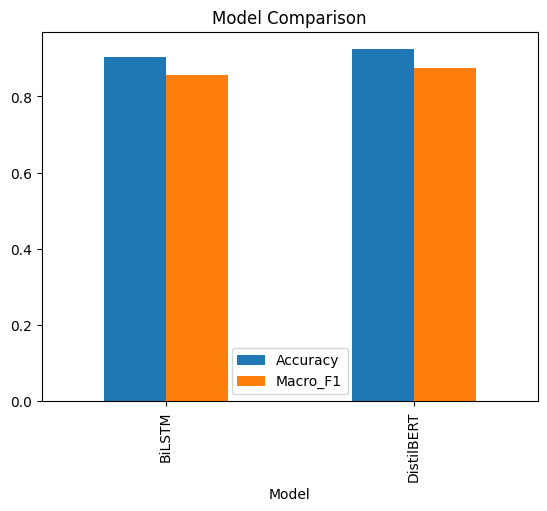

In [39]:
comparison_df.plot(x="Model", y=["Accuracy","Macro_F1"], kind="bar")
plt.title("Model Comparison")
plt.show()

<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">Save Model</div>


In [41]:
trainer.save_model("./saved_model")
tokenizer_bert.save_pretrained("./saved_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./saved_model/tokenizer_config.json', './saved_model/tokenizer.json')

<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">predict</div>


In [42]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

MODEL_PATH = "./saved_model"
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH
)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [45]:
import torch.nn.functional as F
import torch

emotion_map = {
    0:"sadness",
    1:"joy",
    2:"love",
    3:"anger",
    4:"fear",
    5:"surprise"
}



def predict_emotion(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits,
    dim=1
        )

        confidence = probs.max().item()

        pred = probs.argmax().item()

    return {
        "emotion": emotion_map[pred],
        "confidence": confidence
    }

text = "I feel anxious and scared"
emotion = predict_emotion(text)
print(emotion)

In [46]:
predict_emotion(text)

{'emotion': 'fear', 'confidence': 0.9980934262275696}

<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">Save To Hugging Face</div>


In [51]:
pip install huggingface_hub

In [54]:
!hf auth login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? [y/N]: y
Token is valid (permission: write).
The token `upload` has been saved to /root/.cache/huggingface/stored_tokens
Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate when p

In [56]:
!hf upload ahmedsharaf/emotion-classifier ./saved_model

Start hashing 5 files.
Finished hashing 5 files.
Processing Files (0 / 0)      : |          |  0.00B /  0.00B            
New Data Upload               : |          |  0.00B /  0.00B            

  ...d_model/training_args.bin: 100% 5.14k/5.14k [00:00<?, ?B/s]

Processing Files (1 / 2)      :   0% 5.14k/268M [00:00<8:07:26, 9.16kB/s,   ???B/s  ]


  ...d_model/model.safetensors:   2% 5.86M/268M [00:00<?, ?B/s]

  ...d_model/training_args.bin: 100% 5.14k/5.14k [00:00<?, ?B/s]


Processing Files (1 / 2)      :   2% 5.87M/268M [00:00<00:28, 9.13MB/s,  573kB/s  ]  

  ...d_model/training_args.bin: 100% 5.14k/5.14k [00:00<?, ?B/s]


Processing Files (1 / 2)      :   2% 5.95M/268M [00:01<00:43, 5.96MB/s,  567kB/s  ]

  ...d_model/training_args.bin: 100% 5.14k/5.14k [00:00<?, ?B/s]


Processing Files (1 / 2)      :   3% 8.64M/268M [00:01<00:34, 7.61MB/s,  813kB/s  ]

  ...d_model/training_args.bin: 100% 5.14k/5.14k [00:01<?, ?B/s]


Processing Files (1 / 2)      :   3% 9.21M/268M [00:01<00:44